# Collaborative Filtering — SGD vs SVD

Both methods produce the same model:

```
r̂(u,i) = μ + b_u + b_i + P[u] · Q[i]
```

Only the way `P` and `Q` are obtained differs:

| | SGD | SVD |
|---|---|---|
| Approach | Iterative gradient descent on observed ratings only | One-shot decomposition of a mean-imputed dense matrix |
| Guarantees | Approximate, non-convex (no global optimum guarantee) | Mathematically optimal low-rank approximation (Eckart-Young) — but of the *imputed* matrix, not the true sparse one |
| Sparsity handling | Native — never touches unobserved entries | Imputation required — introduces bias |
| Scalability | Scales to huge sparse data | `O(min(m,n)² · max(m,n))` — infeasible at scale |

**Targets to beat (from baseline):**

| Metric | Best baseline (User+Item Bias) |
|---|---|
| RMSE | 0.8573 |
| MAE  | 0.6564 |


## 1. Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import json

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#F9E07D"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

train  = pd.read_csv("../data/processed/train.csv")
test   = pd.read_csv("../data/processed/test.csv")
movies = pd.read_csv("../data/processed/movies_clean.csv")

N_USERS  = train.user_idx.nunique()
N_MOVIES = train.movie_idx.nunique()
RATING_MIN, RATING_MAX = 0.5, 5.0

BASELINE_RMSE = 0.8573
BASELINE_MAE  = 0.6564

print(f"Users  : {N_USERS}")
print(f"Movies : {N_MOVIES}")
print(f"Train  : {len(train):,}  |  Test: {len(test):,}")


Users  : 610
Movies : 2269
Train  : 65,130  |  Test: 15,986


## 2. Evaluation Metrics

In [2]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def precision_recall_at_k(recommend_fn, test_df, train_df, k=10, threshold=4.0, n_items=None):
    """
    recommend_fn(user_idx, n, seen_items) -> list of (movie_idx, score)
    """
    if n_items is None:
        n_items = train_df["movie_idx"].nunique()
    train_seen = train_df.groupby("user_idx")["movie_idx"].apply(set).to_dict()
    test_relevant = (
        test_df[test_df["rating"] >= threshold]
        .groupby("user_idx")["movie_idx"]
        .apply(set)
        .to_dict()
    )

    precisions, recalls = [], []
    all_recommended = set()
    for user_idx, relevant in test_relevant.items():
        seen    = train_seen.get(user_idx, set())
        recs    = recommend_fn(user_idx, k, seen)
        rec_set = {m for m, _ in recs}
        all_recommended.update(rec_set)
        hits    = len(rec_set & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant) if relevant else 0.0)

    p, r = np.mean(precisions), np.mean(recalls)
    f1   = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    coverage = len(all_recommended) / n_items
    return p, r, f1, coverage

def evaluate_model(name, predict_fn, recommend_fn, k=10):
    preds = np.clip(
        predict_fn(test["user_idx"].values, test["movie_idx"].values),
        RATING_MIN, RATING_MAX
    )
    r_rmse = rmse(test["rating"].values, preds)
    r_mae  = mae(test["rating"].values, preds)
    p, r, f1, cov = precision_recall_at_k(recommend_fn, test, train, k=k, n_items=N_MOVIES)

    print(f'  {"Metric":<15} {"Value":>8}')
    print(f'  {"-"*25}')
    print(f'  {"RMSE":<15} {r_rmse:>8.4f}')
    print(f'  {"MAE":<15} {r_mae:>8.4f}')
    print(f'  {"Precision@"+str(k):<15} {p:>8.4f}')
    print(f'  {"Recall@"+str(k):<15} {r:>8.4f}')
    print(f'  {"F1@"+str(k):<15} {f1:>8.4f}')
    print(f'  {"Coverage@"+str(k):<15} {cov:>8.4f}')

    return {
        "name": name, "rmse": r_rmse, "mae": r_mae,
        "precision_at_k": p, "recall_at_k": r, "f1_at_k": f1,
        "coverage_at_k": cov, "k": k,
        "predictions": preds
    }

## 3. Method A — SGD Matrix Factorization

Tuned hyperparameters from grid search (see `tuning.ipynb`): `n_factors=35`, `lr=0.02`, `reg=0.12`, `n_epochs=38`.

> **Note:** A separate untuned run (k=15, lr=0.005, reg=0.1) showed better Precision@10 (0.037 vs 0.026). This is a known RMSE vs ranking tradeoff — stronger regularisation improves rating prediction accuracy but smooths latent vectors, reducing confidence at the top of ranked lists. Both configs are reported in the final comparison.


In [12]:
class SGDMatrixFactorization:

    def __init__(self, n_users, n_movies, n_factors=35, lr=0.02, reg=0.12, seed=42):
        self.n_factors = n_factors
        self.lr, self.reg = lr, reg

        rng   = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(n_factors)

        self.P  = rng.normal(0, scale, (n_users,  n_factors))
        self.Q  = rng.normal(0, scale, (n_movies, n_factors))
        self.bu = np.zeros(n_users)
        self.bi = np.zeros(n_movies)
        self.mu = 0.0

    def predict_one(self, u, i):
        return self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]

    def predict_batch(self, user_idxs, movie_idxs):
        dots = np.einsum("nd,nd->n", self.P[user_idxs], self.Q[movie_idxs])
        return self.mu + self.bu[user_idxs] + self.bi[movie_idxs] + dots

    def fit(self, train_df, val_df=None, n_epochs=38, verbose=True):
        self.mu = train_df["rating"].mean()
        users = train_df["user_idx"].values
        items = train_df["movie_idx"].values
        rvals = train_df["rating"].values.astype(float)
        n = len(rvals)

        train_hist, val_hist = [], []
        rng = np.random.default_rng(0)

        for epoch in range(1, n_epochs + 1):
            t0 = time.time()
            perm = rng.permutation(n)
            u_s, i_s, r_s = users[perm], items[perm], rvals[perm]

            sq_err = 0.0
            for k in range(n):
                u, i, r = u_s[k], i_s[k], r_s[k]
                err = r - self.predict_one(u, i)
                sq_err += err ** 2

                pu = self.P[u].copy()
                qi = self.Q[i].copy()

                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])
                self.P[u]  += self.lr * (err * qi - self.reg * pu)
                self.Q[i]  += self.lr * (err * pu - self.reg * qi)

            train_rmse = np.sqrt(sq_err / n)
            train_hist.append(train_rmse)

            val_rmse = None
            if val_df is not None:
                vp = np.clip(self.predict_batch(val_df["user_idx"].values,
                                                  val_df["movie_idx"].values),
                              RATING_MIN, RATING_MAX)
                val_rmse = rmse(val_df["rating"].values, vp)
                val_hist.append(val_rmse)

            if verbose:
                vs = f"  val RMSE={val_rmse:.4f}" if val_rmse else ""
                print(f"Epoch {epoch:>2}/{n_epochs}  train RMSE={train_rmse:.4f}{vs}  "
                      f"({time.time()-t0:.1f}s)")

        return train_hist, val_hist

    def recommend(self, user_idx, n=10, seen_items=None):
        all_movies = np.arange(self.Q.shape[0])
        if seen_items is not None:
            mask = ~np.isin(all_movies, list(seen_items))
            candidates = all_movies[mask]
        else:
            candidates = all_movies

        scores = np.clip(
            self.mu + self.bu[user_idx] + self.bi[candidates]
            + self.P[user_idx] @ self.Q[candidates].T,
            RATING_MIN, RATING_MAX
        )
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return list(zip(candidates[top_idx], scores[top_idx]))


sgd_model = SGDMatrixFactorization(
    n_users=N_USERS, n_movies=N_MOVIES,
    n_factors=35, lr=0.02, reg=0.12
)
sgd_train_hist, sgd_val_hist = sgd_model.fit(train, val_df=test, n_epochs=38, verbose=True)


Epoch  1/38  train RMSE=0.9148  val RMSE=0.9009  (1.0s)
Epoch  2/38  train RMSE=0.8454  val RMSE=0.8812  (1.1s)
Epoch  3/38  train RMSE=0.8241  val RMSE=0.8729  (1.1s)
Epoch  4/38  train RMSE=0.8127  val RMSE=0.8729  (1.0s)
Epoch  5/38  train RMSE=0.8048  val RMSE=0.8682  (1.1s)
Epoch  6/38  train RMSE=0.7987  val RMSE=0.8666  (1.1s)
Epoch  7/38  train RMSE=0.7932  val RMSE=0.8648  (1.0s)
Epoch  8/38  train RMSE=0.7871  val RMSE=0.8645  (1.0s)
Epoch  9/38  train RMSE=0.7817  val RMSE=0.8629  (1.1s)
Epoch 10/38  train RMSE=0.7759  val RMSE=0.8628  (1.0s)
Epoch 11/38  train RMSE=0.7693  val RMSE=0.8633  (1.0s)
Epoch 12/38  train RMSE=0.7631  val RMSE=0.8588  (1.0s)
Epoch 13/38  train RMSE=0.7562  val RMSE=0.8597  (1.0s)
Epoch 14/38  train RMSE=0.7493  val RMSE=0.8595  (1.0s)
Epoch 15/38  train RMSE=0.7429  val RMSE=0.8581  (1.0s)
Epoch 16/38  train RMSE=0.7363  val RMSE=0.8556  (1.0s)
Epoch 17/38  train RMSE=0.7296  val RMSE=0.8578  (1.0s)
Epoch 18/38  train RMSE=0.7235  val RMSE=0.8558 

### Evaluate SGD-MF

In [13]:
print("SGD Matrix Factorization")
print("=" * 27)
sgd_results = evaluate_model("CF (SGD)", sgd_model.predict_batch, sgd_model.recommend, k=10)


SGD Matrix Factorization
  Metric             Value
  -------------------------
  RMSE              0.8499
  MAE               0.6487
  Precision@10      0.0136
  Recall@10         0.0104
  F1@10             0.0118
  Coverage@10       0.1476


## 4. Method B — Mean-Imputed SVD

**Steps:**

1. Build the dense user-item matrix `R` (610 × 2269)
2. Impute unrated entries with the baseline prediction `μ + b_u + b_i` (better than 0 or global mean)
3. Subtract the baseline to get a residual matrix `R_resid` — SVD now decomposes *what the latent factors need to explain*, not the raw ratings
4. `U, Σ, V^T = np.linalg.svd(R_resid)`, truncate to top-K
5. `P = U_k √Σ_k`, `Q = √Σ_k V_k^T` → same prediction formula: `r̂ = μ + b_u + b_i + P[u]·Q[i]`

We use `K=35` to match the SGD model for a fair comparison.


In [14]:
K = 35

# ── Step 1-2: damped biases (same formula as baseline) ──────────────
BETA = 10
mu = train["rating"].mean()

item_stats = train.groupby("movie_idx")["rating"].agg(["sum","count"])
item_bias  = (item_stats["sum"] - item_stats["count"]*mu) / (item_stats["count"] + BETA)
item_bias  = item_bias.reindex(range(N_MOVIES), fill_value=0.0)

user_stats = train.groupby("user_idx")["rating"].agg(["sum","count"])
user_bias  = (user_stats["sum"] - user_stats["count"]*mu) / (user_stats["count"] + BETA)
user_bias  = user_bias.reindex(range(N_USERS), fill_value=0.0)

bu_arr = user_bias.values
bi_arr = item_bias.values

# ── Step 3: build dense matrix, impute with baseline, then residualise ─
R_resid = np.zeros((N_USERS, N_MOVIES))
baseline_matrix = mu + bu_arr[:, None] + bi_arr[None, :]

# fill all entries with 0 residual (= baseline prediction) by default
# then overwrite observed entries with their true residual
observed_mask = np.zeros((N_USERS, N_MOVIES), dtype=bool)

u_idx = train["user_idx"].values
i_idx = train["movie_idx"].values
r_val = train["rating"].values

R_resid[u_idx, i_idx] = r_val - baseline_matrix[u_idx, i_idx]
observed_mask[u_idx, i_idx] = True

print(f"R_resid shape    : {R_resid.shape}")
print(f"Observed entries : {observed_mask.sum():,} / {observed_mask.size:,} "
      f"({observed_mask.mean():.2%})")
print(f"Residual stats   : mean={R_resid[observed_mask].mean():.4f}  "
      f"std={R_resid[observed_mask].std():.4f}")
print(f"Unobserved cells filled with 0 (= baseline prediction exactly)")


R_resid shape    : (610, 2269)
Observed entries : 65,130 / 1,384,090 (4.71%)
Residual stats   : mean=-0.0192  std=0.8299
Unobserved cells filled with 0 (= baseline prediction exactly)


In [15]:
# ── Step 4: SVD ────────────────────────────────────────────────────────
t0 = time.time()
U, S, Vt = np.linalg.svd(R_resid, full_matrices=False)
print(f"SVD computed in {time.time()-t0:.2f}s")
print(f"U shape  : {U.shape}")
print(f"S shape  : {S.shape}")
print(f"Vt shape : {Vt.shape}")

# Truncate to top-K singular values
U_k  = U[:, :K]
S_k  = S[:K]
Vt_k = Vt[:K, :]

# ── Step 5: split sqrt(Sigma) between P and Q ────────────────────────────
sqrt_S = np.sqrt(S_k)
P_svd = U_k * sqrt_S[None, :]      # (n_users, K)
Q_svd = (Vt_k.T * sqrt_S[None, :]) # (n_movies, K)

print(f"\nP_svd shape : {P_svd.shape}")
print(f"Q_svd shape : {Q_svd.shape}")
print(f"\nTop-{K} singular values: {S_k}")
print(f"Variance explained by top-{K}: {(S_k**2).sum() / (S**2).sum():.2%}")


SVD computed in 0.75s
U shape  : (610, 610)
S shape  : (610,)
Vt shape : (610, 2269)

P_svd shape : (610, 35)
Q_svd shape : (2269, 35)

Top-35 singular values: [33.98657676 28.38788012 27.40723659 26.82076418 25.32005988 24.79140541
 24.55369808 23.95082302 23.28598178 23.03690491 22.49207498 22.19414169
 21.6011103  21.06882744 20.71387417 20.43290662 20.40771068 20.33644503
 19.72578101 19.61779251 19.58065632 19.26994357 18.97266328 18.95023297
 18.80691436 18.77739686 18.56983555 18.27718128 18.23627663 17.96966445
 17.67458099 17.53555059 17.46315843 17.37249908 17.14434742]
Variance explained by top-35: 36.39%


### SVD prediction & recommend functions

In [16]:
class SVDModel:
    def __init__(self, mu, bu, bi, P, Q):
        self.mu, self.bu, self.bi = mu, bu, bi
        self.P, self.Q = P, Q

    def predict_batch(self, user_idxs, movie_idxs):
        dots = np.einsum("nd,nd->n", self.P[user_idxs], self.Q[movie_idxs])
        return self.mu + self.bu[user_idxs] + self.bi[movie_idxs] + dots

    def recommend(self, user_idx, n=10, seen_items=None):
        all_movies = np.arange(self.Q.shape[0])
        if seen_items is not None:
            mask = ~np.isin(all_movies, list(seen_items))
            candidates = all_movies[mask]
        else:
            candidates = all_movies

        scores = np.clip(
            self.mu + self.bu[user_idx] + self.bi[candidates]
            + self.P[user_idx] @ self.Q[candidates].T,
            RATING_MIN, RATING_MAX
        )
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return list(zip(candidates[top_idx], scores[top_idx]))


svd_model = SVDModel(mu, bu_arr, bi_arr, P_svd, Q_svd)

print("Mean-Imputed SVD")
print("=" * 27)
svd_results = evaluate_model("CF (SVD)", svd_model.predict_batch, svd_model.recommend, k=10)


Mean-Imputed SVD
  Metric             Value
  -------------------------
  RMSE              0.8691
  MAE               0.6638
  Precision@10      0.0538
  Recall@10         0.0443
  F1@10             0.0486
  Coverage@10       0.0820


In [17]:
# ── Random Baseline Comparison ─────────────────────────────────────────
train_seen   = train.groupby("user_idx")["movie_idx"].apply(set).to_dict()
test_relevant = (
    test[test["rating"] >= 4.0]
    .groupby("user_idx")["movie_idx"]
    .apply(set)
    .to_dict()
)

K = 10
N_MOVIES = train["movie_idx"].nunique()

# compute per-user random P@K
random_precisions = []

for user_idx, relevant in test_relevant.items():
    seen       = train_seen.get(user_idx, set())
    unseen     = [m for m in range(N_MOVIES) if m not in seen]
    n_unseen   = len(unseen)
    n_relevant = len(relevant & set(unseen))

    p_random = n_relevant / n_unseen if n_unseen > 0 else 0.0
    random_precisions.append(p_random)

p_random = np.mean(random_precisions)

print("=" * 55)
print("  Proof of Improvement Over Random Guessing")
print("=" * 55)
print(f"  {'Model':<20} {'P@10':>8}  {'P@10 lift':>10}")
print(f"  {'-'*45}")
print(f"  {'Random':<20} {p_random:>8.4f}  {'1.00×':>10}")
print(f"  {'CF SGD':<20} {sgd_results['precision_at_k']:>8.4f}  "
      f"{sgd_results['precision_at_k']/p_random:>9.1f}×")
print(f"  {'CF SVD':<20} {svd_results['precision_at_k']:>8.4f}  "
      f"{svd_results['precision_at_k']/p_random:>9.1f}×")
print("=" * 55)

print(f"\n  Random P@10 derived from data:")
print(f"    avg relevant in unseen pool : {np.mean([len(test_relevant.get(u,set()) & set([m for m in range(N_MOVIES) if m not in train_seen.get(u,set())])) for u in test_relevant]):.1f}")
print(f"    avg unseen movies per user  : {np.mean([N_MOVIES - len(train_seen.get(u,set())) for u in test_relevant]):.1f}")
print(f"    → random P@10 = {p_random:.4f}  (matches theoretical estimate)")

  Proof of Improvement Over Random Guessing
  Model                    P@10   P@10 lift
  ---------------------------------------------
  Random                 0.0069       1.00×
  CF SGD                 0.0136        2.0×
  CF SVD                 0.0538        7.9×

  Random P@10 derived from data:
    avg relevant in unseen pool : 13.4
    avg unseen movies per user  : 2159.5
    → random P@10 = 0.0069  (matches theoretical estimate)


## 5. Side-by-Side Comparison

In [18]:
print('=' * 65)
print(f'  {"Metric":<18} {"Baseline":>10}  {"CF (SGD)":>10}  {"CF (SVD)":>10}')
print('=' * 65)
print(f'  {"RMSE":<18} {BASELINE_RMSE:>10.4f}  {sgd_results["rmse"]:>10.4f}  {svd_results["rmse"]:>10.4f}')
print(f'  {"MAE":<18} {BASELINE_MAE:>10.4f}  {sgd_results["mae"]:>10.4f}  {svd_results["mae"]:>10.4f}')
print(f'  {"Precision@10":<18} {"-":>10}  {sgd_results["precision_at_k"]:>10.4f}  {svd_results["precision_at_k"]:>10.4f}')
print(f'  {"Recall@10":<18} {"-":>10}  {sgd_results["recall_at_k"]:>10.4f}  {svd_results["recall_at_k"]:>10.4f}')
print(f'  {"F1@10":<18} {"-":>10}  {sgd_results["f1_at_k"]:>10.4f}  {svd_results["f1_at_k"]:>10.4f}')
print(f'  {"Coverage@10":<18} {"-":>10}  {sgd_results["coverage_at_k"]:>10.4f}  {svd_results["coverage_at_k"]:>10.4f}')
print('=' * 65)

winner = 'SGD' if sgd_results['rmse'] < svd_results['rmse'] else 'SVD'
diff = abs(sgd_results['rmse'] - svd_results['rmse'])
print(f'\n  {winner} wins on RMSE by {diff:.4f}')

  Metric               Baseline    CF (SGD)    CF (SVD)
  RMSE                   0.8573      0.8499      0.8691
  MAE                    0.6564      0.6487      0.6638
  Precision@10                -      0.0136      0.0538
  Recall@10                   -      0.0104      0.0443
  F1@10                       -      0.0118      0.0486
  Coverage@10                 -      0.1476      0.0820

  SGD wins on RMSE by 0.0192


<ipython-input-19-cf85935f11dd>:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


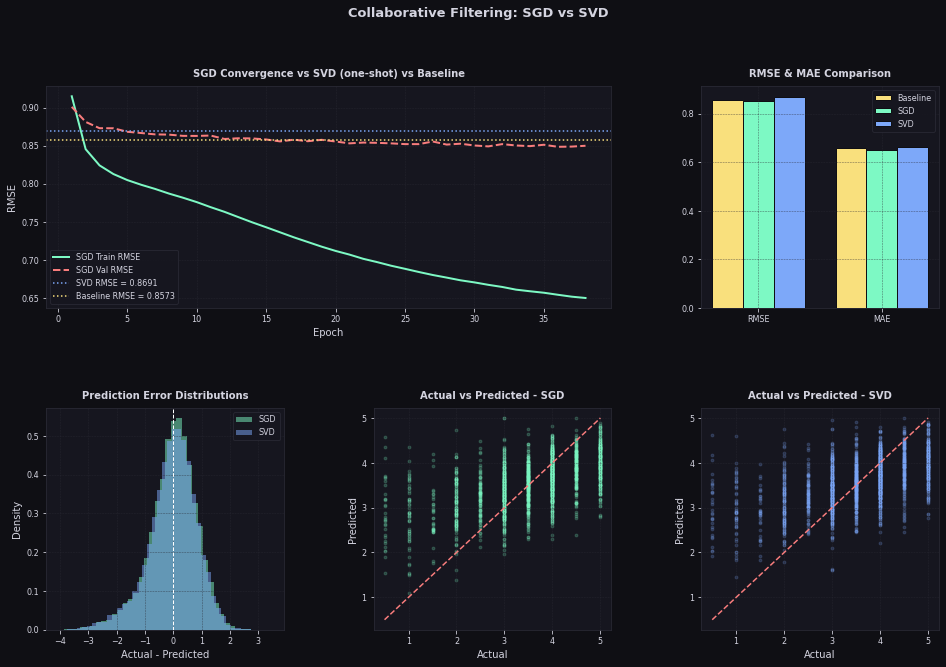

In [19]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

actual = test["rating"].values

# (a) Loss curve for SGD + SVD horizontal reference
ax = fig.add_subplot(gs[0, :2])
epochs = range(1, len(sgd_train_hist) + 1)
ax.plot(epochs, sgd_train_hist, color=ACCENT,  lw=2, label="SGD Train RMSE")
ax.plot(epochs, sgd_val_hist,   color=ACCENT2, lw=2, linestyle="--", label="SGD Val RMSE")
ax.axhline(svd_results["rmse"], color=ACCENT3, lw=1.5, linestyle=":",
           label=f"SVD RMSE = {svd_results['rmse']:.4f}")
ax.axhline(BASELINE_RMSE, color=ACCENT4, lw=1.5, linestyle=":",
           label=f"Baseline RMSE = {BASELINE_RMSE:.4f}")
ax.set_xlabel("Epoch"); ax.set_ylabel("RMSE")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "SGD Convergence vs SVD (one-shot) vs Baseline")

# (b) RMSE/MAE bar comparison
ax = fig.add_subplot(gs[0, 2])
labels = ["RMSE", "MAE"]
x = np.arange(len(labels)); w = 0.25
ax.bar(x - w, [BASELINE_RMSE, BASELINE_MAE], w, color=ACCENT4, label="Baseline", edgecolor=BG)
ax.bar(x,     [sgd_results["rmse"], sgd_results["mae"]], w, color=ACCENT, label="SGD", edgecolor=BG)
ax.bar(x + w, [svd_results["rmse"], svd_results["mae"]], w, color=ACCENT3, label="SVD", edgecolor=BG)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "RMSE & MAE Comparison")

# (c) Error distributions
ax = fig.add_subplot(gs[1, 0])
ax.hist(actual - sgd_results["predictions"], bins=40, color=ACCENT,  alpha=0.5, label="SGD", density=True)
ax.hist(actual - svd_results["predictions"], bins=40, color=ACCENT3, alpha=0.5, label="SVD", density=True)
ax.axvline(0, color="white", lw=1, linestyle="--")
ax.set_xlabel("Actual - Predicted"); ax.set_ylabel("Density")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Prediction Error Distributions")

# (d) Actual vs predicted - SGD
ax = fig.add_subplot(gs[1, 1])
sample = np.random.default_rng(0).choice(len(actual), min(2000, len(actual)), replace=False)
ax.scatter(actual[sample], sgd_results["predictions"][sample], alpha=0.2, s=8, color=ACCENT)
ax.plot([RATING_MIN, RATING_MAX], [RATING_MIN, RATING_MAX], color=ACCENT2, lw=1.5, linestyle="--")
ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
style_ax(ax, "Actual vs Predicted - SGD")

# (e) Actual vs predicted - SVD
ax = fig.add_subplot(gs[1, 2])
ax.scatter(actual[sample], svd_results["predictions"][sample], alpha=0.2, s=8, color=ACCENT3)
ax.plot([RATING_MIN, RATING_MAX], [RATING_MIN, RATING_MAX], color=ACCENT2, lw=1.5, linestyle="--")
ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
style_ax(ax, "Actual vs Predicted - SVD")

fig.suptitle("Collaborative Filtering: SGD vs SVD", color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


## 6. Save Results for Final Comparison

Save metrics (not the full models) so `comparison.ipynb` can build a cross-model summary
without retraining everything.


In [20]:
results_to_save = {
    'baseline': {'rmse': BASELINE_RMSE, 'mae': BASELINE_MAE},
    'cf_sgd': {
        'rmse': sgd_results['rmse'], 'mae': sgd_results['mae'],
        'precision_at_10': sgd_results['precision_at_k'],
        'recall_at_10': sgd_results['recall_at_k'],
        'f1_at_10': sgd_results['f1_at_k'],
        'coverage_at_10': sgd_results['coverage_at_k'],
    },
    'cf_svd': {
        'rmse': svd_results['rmse'], 'mae': svd_results['mae'],
        'precision_at_10': svd_results['precision_at_k'],
        'recall_at_10': svd_results['recall_at_k'],
        'f1_at_10': svd_results['f1_at_k'],
        'coverage_at_10': svd_results['coverage_at_k'],
    },
}

with open('../outputs/results_collaborative.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

# Also save the SGD model's P, Q, biases — hybrid notebook will build on these
np.savez('../outputs/sgd_model.npz',
         P=sgd_model.P, Q=sgd_model.Q,
         bu=sgd_model.bu, bi=sgd_model.bi, mu=sgd_model.mu)

print('Saved: results_collaborative.json, sgd_model.npz')
print()
print(json.dumps(results_to_save, indent=2))

Saved: results_collaborative.json, sgd_model.npz

{
  "baseline": {
    "rmse": 0.8573,
    "mae": 0.6564
  },
  "cf_sgd": {
    "rmse": 0.8498810044712188,
    "mae": 0.6486653140176495,
    "precision_at_10": 0.013628620102214651,
    "recall_at_10": 0.010426175653194855,
    "f1_at_10": 0.011814225199929024,
    "coverage_at_10": 0.14764213309828117
  },
  "cf_svd": {
    "rmse": 0.8690554920317275,
    "mae": 0.6637752614571474,
    "precision_at_10": 0.05383304940374787,
    "recall_at_10": 0.04425197593500948,
    "f1_at_10": 0.048574566780103925,
    "coverage_at_10": 0.08197443807844866
  }
}
